In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import torch
from torch import nn
import os,json
if os.path.split(os.getcwd())[-1] != 'structure-from-sound-python':
    os.chdir("../")
np.set_printoptions(linewidth=200)
import src.tdoa_vector_to_position as tdoa_lib
import glob

# Settings

In [2]:
experiment = "music_0008"
noise_std = 0.1 # estimated noise of detections

fig_folder ="./results/detections/tdoa_20201016/figs/"
path = "./results/detections/tdoa_20201016/tdoa/" + experiment + "/"
#det_path = "./results/detections/tdoa_20201016/tdoa/" # folder with detections

In [3]:
# Loading tdoa-vector

tdoa = np.load(path + "tdoa_vectors.npy").T
tdoa_times = np.load(path + "tdoa_vector_times.npy").T
tdoa_df = pd.DataFrame(tdoa)
tdoa = tdoa_df.to_numpy()
tdoa_df

# Loading ground truth
case_folder = "./results/detections/tdoa_20201016/data_gt/" + experiment + "/"
df_pos  = pd.read_csv(os.path.join(case_folder, "gt_positions.csv"))
info = json.load(open(os.path.join(case_folder, "info.json"),'r'))
n = info["number_of_mics"]
t = df_pos.shape[0]

positions = {"mics": np.zeros((n,3,t)), "speaker": np.zeros((3,t))}

time = np.array(df_pos['time'])

dims = ['x','y','z']
for i in range(n):
    for j,d in enumerate(dims):
        positions["mics"][i,j,:] = df_pos['mic' + str(i+1) + "_" + d]
for j,d in enumerate(dims):
    positions["speaker"][j,:] = df_pos['speaker' + "_" + d]
r_gt = np.nanmedian(positions["mics"],axis=2).T
s_gt = np.stack([np.interp(tdoa_times,time, positions["speaker"][i]) for i in range(3)])

Text(0.5, 0, 'meters')

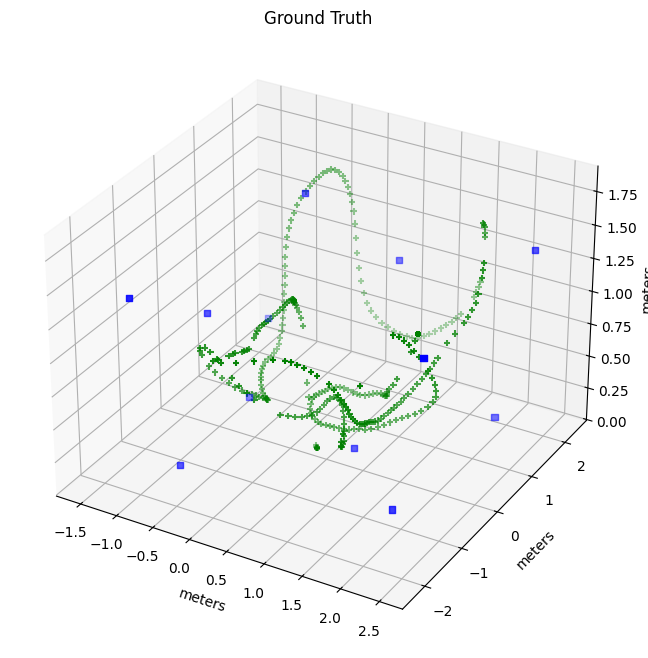

In [4]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')


ax.scatter(r_gt[0],
           r_gt[1], r_gt[2], c='b', marker="s")

ax.scatter(s_gt[0],
           s_gt[1], s_gt[2], c='g', marker="+")
plt.title("Ground Truth")
ax.set_xlabel('meters')
ax.set_ylabel('meters')
ax.set_zlabel('meters')

Text(0.5, 1.0, 'Relaxed residuals : music_0008')

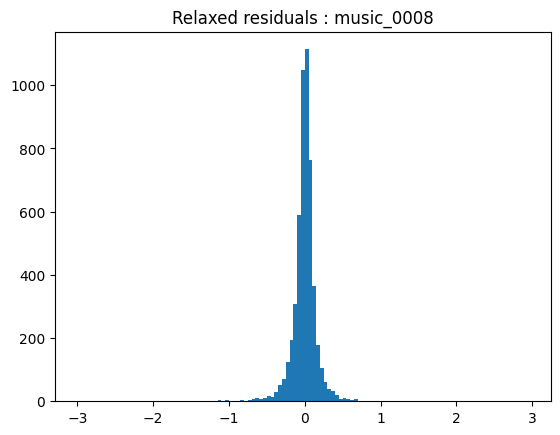

In [ ]:
tp = tdoa_lib.TxoaProblem(tdoa, tol=noise_std, tol_std=3)
tp.solve_for_offset(tdoa_lib.OffsetSolver95, outer_ransac_iters=1000)
tp.bundle(steps=100)
tp.ransac_expand_to_all_rows()
tp.bundle(steps=10000, lr=1e-3)
# Re-estimate all rows and columns
tp.ransac_reestimated_to_all_rows()
tp.bundle(steps=10000, lr=1e-3)
tp.ransac_reestimated_to_all_cols()
tp.bundle(steps=10000, lr=1e-3)
plt.hist(tp.get_residuals().flatten(),np.arange(-3,3,0.05));
plt.title("Relaxed residuals : " + experiment)
#plt.savefig(fig_folder + experiment + "_relaxed_residual.png")


In [27]:
# tp.bundle(steps=1000)
# tp.bundle_extra_constraint(steps=1000,lmbda=0.1)
# tp.bundle_extra_constraint(steps=1000,lmbda=100)
# tp.bundle_extra_constraint(steps=1000,lmbda=1000000, lr=3e-2)
# tp.ransac_reestimated_to_all_rows(ransac_iter=100)
# tp.bundle_extra_constraint(steps=1000,lmbda=1000000, lr=3e-2)
# tp.ransac_reestimated_to_all_cols(ransac_iter=100)
# tp.bundle_extra_constraint(steps=10000,lmbda=1000000, lr=3e-2)
# u,v,a,b,o = tp.sol.u, tp.sol.v, tp.sol.a, tp.sol.b,tp.sol.o
# print(f"Median error of relaxation constraint {np.median(np.abs(np.concatenate([np.diag(u.T@u) - a.T, np.diag(v.T@v) - b],axis=1))):.2f}")
# R,S = tp.sol.u, tp.sol.v

In [28]:
R,S = tp.upgrade(ransac_iter=1000)

most_inliers=4170, out of 5412


Text(0.5, 1.0, 'Relaxed residuals (after upgrade)')

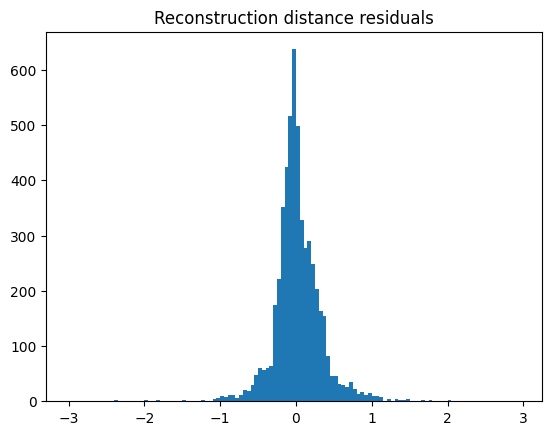

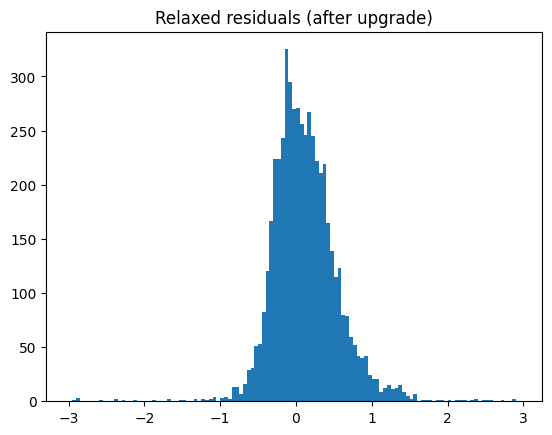

In [29]:
est = np.sqrt(np.sum((np.expand_dims(R.T,1) - np.expand_dims(S.T,0))**2,axis=2))
res = tp.data - tp.sol.o - est
plt.hist((res).flatten(), bins=np.arange(-3,3,0.05));
plt.title("Reconstruction distance residuals")
plt.figure()
plt.hist(tp.get_residuals().flatten(),np.arange(-3,3,0.05));
plt.title("Relaxed residuals (after upgrade)")

Text(0.5, 1.0, 'Reconstruction distance residuals (after local optimization)')

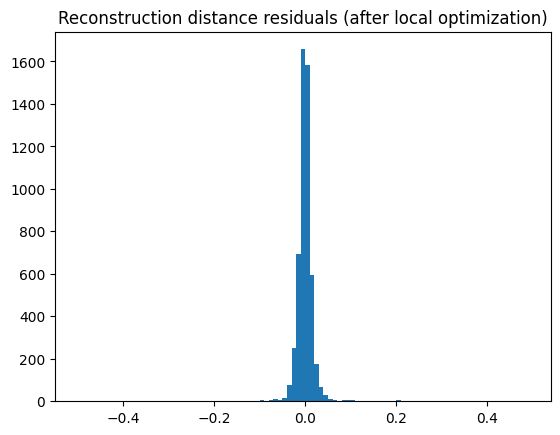

In [30]:
R,S,O = tdoa_lib.local_optimization(tdoa, R,S, tp.sol.o, verbose=False,steps=20000, measurement_noise_std=noise_std,lr=3e-3)
est = np.sqrt(np.sum((np.expand_dims(R.T,1) - np.expand_dims(S.T,0))**2,axis=2))
res = tp.data - O - est
R,S,O = tdoa_lib.local_optimization(tdoa, R,S, O, verbose=False,steps=20000, measurement_noise_std=res[np.abs(res) < 0.5].std(),lr=3e-3)
est = np.sqrt(np.sum((np.expand_dims(R.T,1) - np.expand_dims(S.T,0))**2,axis=2))
res = tp.data - O - est
plt.hist((res).flatten(), bins=np.arange(-0.5,0.5,0.01));
plt.title("Reconstruction distance residuals (after local optimization)")


# Map solution into gt coordinate system

scale 1.0179067525954637
#Mics worse than 10 cm error = 0


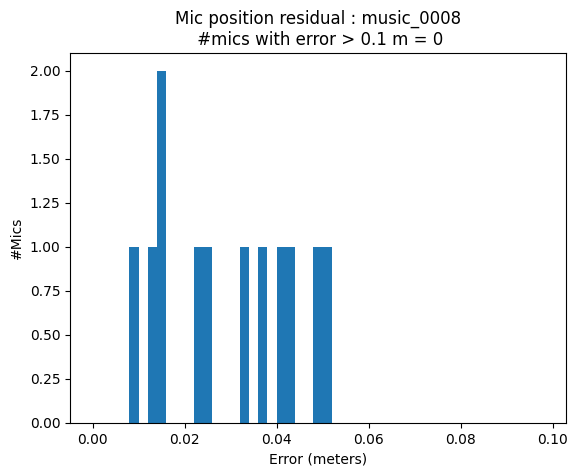

In [31]:
from src import tdoa_datasets_module

Rot, trans = tdoa_datasets_module.procrustes(
    R.T, r_gt.T, tol=0.1, n_iters=10000, rescaling=True)
newR = (R.T @ Rot + trans).T
newS = (S.T @ Rot + trans).T
res = np.sum((newR - r_gt)**2,axis=0)**0.5
plt.hist(res,bins = np.arange(0,0.1,0.002));
plt.title("Mic position residual : " + experiment + "\n #mics with error > 0.1 m = " + str(sum(res > 0.1)))
print(f"#Mics worse than 10 cm error = {sum(res > 0.1)}")
plt.xlabel("Error (meters)")
plt.ylabel("#Mics")
plt.savefig(fig_folder + experiment + "_mic_postional_residual.png")

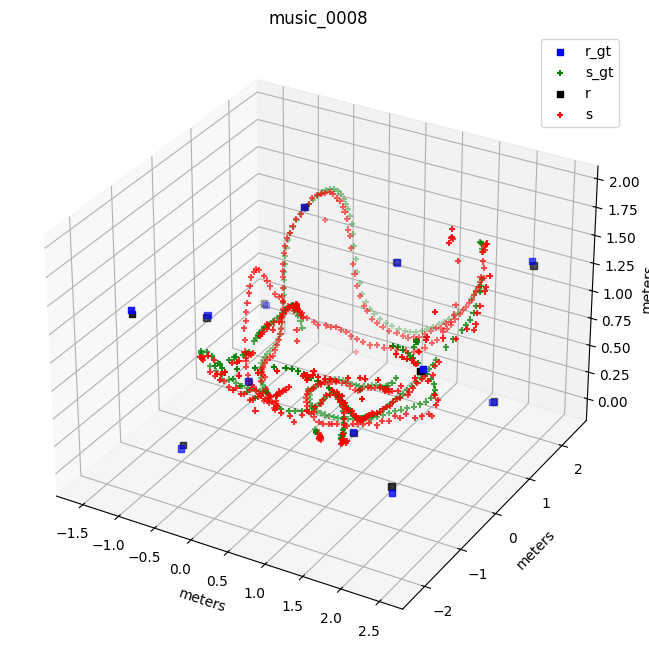

In [32]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')


ax.scatter(r_gt[0],
           r_gt[1], r_gt[2], c='b', marker="s")

ax.scatter(s_gt[0],
           s_gt[1], s_gt[2], c='g', marker="+")

ax.scatter(newR[0],
           newR[1], newR[2], c='k', marker="s")
reasonable_ind = np.all(np.logical_and(
    newS < 3, newS > -3), axis=0)
ax.scatter(newS[0,reasonable_ind],
           newS[1,reasonable_ind], newS[2,reasonable_ind], c='r', marker="+")

ax.legend(["r_gt", "s_gt", "r","s"])
ax.set_xlabel('meters')
ax.set_ylabel('meters')
ax.set_zlabel('meters')
plt.title(experiment)
plt.savefig(fig_folder + experiment + "_3d_plot.png")

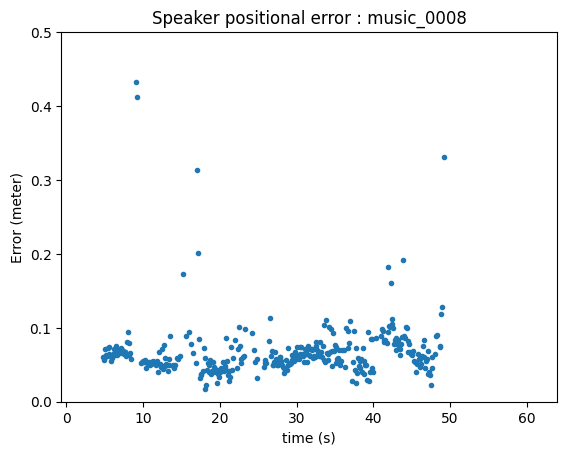

In [33]:
res = np.sum((newS - s_gt)**2,axis=0)**0.5
plt.plot(tdoa_times,res,'.')
plt.ylim(0,0.5)
plt.title("Speaker positional error : " + experiment)
plt.ylabel("Error (meter)")
plt.xlabel("time (s)")
plt.savefig(fig_folder + experiment + "_speaker_position_error.png")
# Think about why you